In [51]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact,fixed,widgets
opciones=dict(continuous_update=False)

Estudiar, como se hizo para el caso de un "gas", la fluctuación en la densidad de un sólido y demostrar, numéricamente los resultados teóricos esperados en este caso (ver teoría en el capítulo 1, problemas 1.2 y 1.3).

Para ello:
- Generar al azar las posiciones de equilibrio de N partículas distribuidas en una "grid" regular de tamaño total L y M celdas por lado (M^3 celdas).  El tamaño de cada celda será Lmol = M.

**Metodología:**
Como primero, haremos la generación de una caja en dos dimensiones llena con partículas, la primera partícula estará ubicada en una esquina de la caja, a partir de ella ubicaremos las otras, desplazandolas un dx en x y un dy en y, de esta manera quedaran uniformemente distribuidas, tal como lo es un sólido

In [3]:
Nr=22
N=Nr**3
L=1
V=L**3
rho_teo=N/V
print(f"Densidad teórica: {rho_teo}")

Densidad teórica: 10648.0


In [4]:
rs=np.zeros((N,3))
dx=L/Nr

contador=0
for i in range(0,22):
  for j in range(0,22):
    for k in range(0,22):
      rs[contador][0]= i*dx + dx/2 
      rs[contador][1]= j*dx + dx/2
      rs[contador][2]= k*dx + dx/2
      contador=contador+1

Text(0.5, 1.0, 'Vista de una cara del sólido')

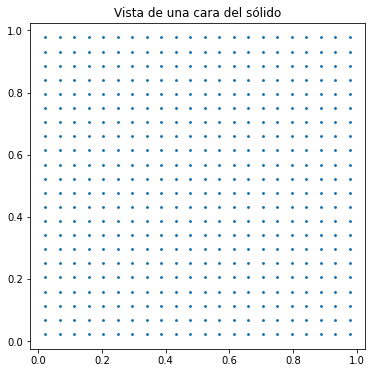

In [6]:
fig,ax=plt.subplots(figsize=(6,6))
ax.scatter(rs[:,0],rs[:,1],s=0.5)
ax.set_title("Vista de una cara del sólido")

Calculemos la densidad cerca al centro de la caja:

In [14]:
#Tamaño de la caja para determinar la densidad
dL=0.5
dV=dL**3
P=[0.5,0.5,0.5] #punto del centro

n=((abs(rs[:,0]-P[0])<=dL/2)&(abs(rs[:,1]-P[1])<=dL/2)&(abs(rs[:,2]-P[2])<=dL/2)).sum()
rho_obs=n/dV
print(f"Densidad observada: {rho_obs}")

Densidad observada: 10848.0


El número de partículas en el volumen de control es:

In [8]:
n

64

El valor de la densidad fluctúa:

In [16]:
Nr=22
N=Nr**3
L=1
V=L**3
rho_teo=N/V
print(f"Densidad teórica: {rho_teo}")

#Tamaño de la caja para determinar la densidad
dL=0.5
dV=dL**3
P=[0.5,0.5,0.5]

n=((abs(rs[:,0]-P[0])<=dL/2)&(abs(rs[:,1]-P[1])<=dL/2)&(abs(rs[:,2]-P[2])<=dL/2)).sum()
rho_obs=n/dV
print(f"Densidad observada: {rho_obs}")
print(f"Error relativo: {abs(rho_obs-rho_teo)/rho_teo} numero {n}")

Densidad teórica: 10648.0
Densidad observada: 10848.0
Error relativo: 0.018782870022539443 numero 1356


Probemos a hacerlo muchas veces. Las partículas de un sólido no se dezplazan de igual manera como lo hacen las de un gas, ellas vibran a lo largo de su posición de equilibrio, por ende simularemos este fenómeno desplazando las partículas de la malla una posición al azar en x y y entre 0 y el tamaño de cada celda (M) 

Densidad teórica: 10648.0


100%|██████████| 100/100 [00:20<00:00,  4.99it/s]


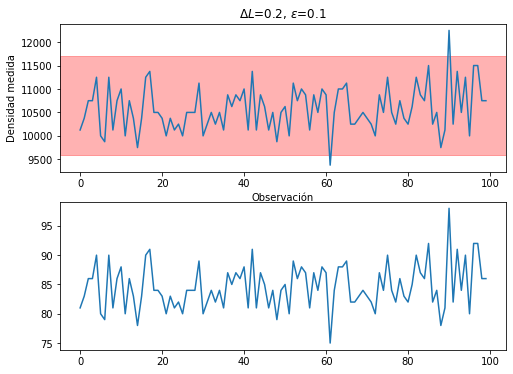

In [12]:
from tqdm import tqdm

Nr=22
N=Nr**3
dx=L/Nr
rs=np.zeros((N,3))


contador=0
for i in range(0,22):
  for j in range(0,22):
    for k in range(0,22):
      rs[contador][0]= i*dx + dx/2 
      rs[contador][1]= j*dx + dx/2
      rs[contador][2]= k*dx + dx/2
      contador=contador+1

L=1
V=L**3
rho_teo=N/V
print(f"Densidad teórica: {rho_teo}")
dL=0.2
dV=dL**3
P=[0.5,0.5,0.5]

rho_obs=[]
ns=[]
for w in tqdm(range(100)):
  contador=0
  for i in range(0,22):
    for j in range(0,22):
      for k in range(0,22):
        rs[contador][0]= i*dx + dx/2 +np.random.uniform(-dx/2,dx/2,1)
        rs[contador][1]= j*dx + dx/2 +np.random.uniform(-dx/2,dx/2,1)
        rs[contador][2]= k*dx + dx/2 +np.random.uniform(-dx/2,dx/2,1)
        contador=contador+1
  n=((abs(rs[:,0]-P[0])<=dL/2)&(abs(rs[:,1]-P[1])<=dL/2)&(abs(rs[:,2]-P[2])<=dL/2)).sum()
  ns+=[n]
  rho_obs+=[n/dV]

fig,axs=plt.subplots(2,1,figsize=(8,6))
eps=0.1

ax=axs[0]
ax.axhspan(rho_teo*(1-eps),rho_teo*(1+eps),color='r',alpha=0.3)
ax.set_title(rf"$\Delta L$={dL}, $\epsilon$={eps}")
ax.plot(rho_obs)
ax.set_xlabel("Observación")
ax.set_ylabel("Densidad medida")


ax=axs[1]
ax.plot(ns)

In [24]:
dLs=np.linspace(0,0.8,10000)
epsilons=np.zeros(len(dLs))

for i in range(10000):
  Nr=22
  N=Nr**3
  L=1
  V=L**3
  rho_teo=N/V
  #print(f"Densidad teórica: {rho_teo}")

  #Tamaño de la caja para determinar la densidad
  dL=dLs[i]
  dV=dL**3
  P=[0.5,0.5,0.5]

  n=((abs(rs[:,0]-P[0])<=dL/2)&(abs(rs[:,1]-P[1])<=dL/2)&(abs(rs[:,2]-P[2])<=dL/2)).sum()
  epsilons[i]=1/(n**0.5)
  rho_obs=n/dV

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:18: RuntimeWarning: divide by zero encountered in double_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:19: RuntimeWarning: invalid value encountered in true_divide


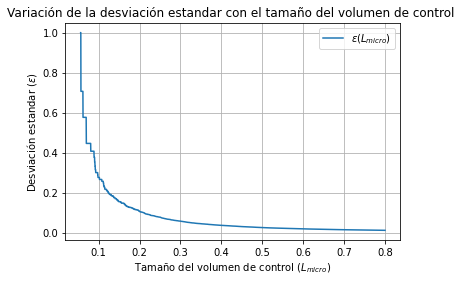

In [73]:
plt.plot(dLs,epsilons, label="$\epsilon(L_{micro})$")
plt.title("Variación de la desviación estandar con el tamaño del volumen de control ")
plt.ylabel(r"Desviación estandar $(\epsilon)$")
plt.xlabel(r"Tamaño del volumen de control ($L_{micro}$)")
plt.grid()
plt.legend()

In [66]:
def ajuste(Lmol=0.05):
  x=np.linspace(0.05,1,10000)

  plt.plot(dLs,epsilons, label="$\epsilon(L_{micro})$")
  plt.plot(x,(Lmol/x)**(3/2),label="$y=(L_{mol}/x)^{3/2} $")
  plt.title("Ajuste del eps con el tamaño del volumen de control")
  plt.ylabel(r"$\epsilon$")
  plt.xlabel(r"$L_{micro}$")
  plt.grid()
  plt.legend()

# Código de interacción
interact(ajuste,
         Lmol=widgets.FloatSlider(min=0.02,max=0.1,step=0.01,value=0.05,**opciones)
        );

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='Lmol', max=0.1, min=0.02, …

# Conclusiones:
Como se pudo observar la variación del flujo de densidad para el caso de solidos es mucho menor para el caso de los sólidos, esto tiene todo el sentido, ya que la densidad depende directamente del número de partículas que se encuentren en el volumen de control, como los sólidos vibran en una posición de equilibrio, el desplazamiento de las partículas no es muy significativo, por ende para un volumen de control alto el número de partículas que se mantendran allí es casi constante.

Por otro lado vimos la dependencia de la desviación estandar con el tamaño del volumen de control, si intentamos ajustar dicha gráfica con la ecuación que vimos en clase:

$$L_{micro}= \frac{L_{mol}}{\varepsilon^{2/3}}$$

$$\varepsilon = \left( \frac{L_{mol}}{L_{micro}} \right)^{3/2}$$

El ajuste es perfecto, por tanto la relación entre Lmicro, Lmol y epsilon es la esperada según la teoría del libro.